In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [75]:
train = pd.read_csv("crime_train.csv")
test = pd.read_csv("crime_test.csv")

In [76]:
print("Training data shape:", train.shape)
print("Test data shape:", test.shape)

train.head()

Training data shape: (22489, 12)
Test data shape: (9639, 12)


,Unnamed: 0,Num,case_filed,city,area,crime_description,age,sex,weapon,domain,police_department,closed
0,19794,19795,04-04-2022 18:00,Mumbai,307,VEHICLE - STOLEN,63.0,X,Poison,Violent Crime,12.0,No
1,13762,13763,07-27-2021 10:00,Surat,504,ROBBERY,57.0,F,Explosives,Violent Crime,3.0,No
2,30311,30312,06-16-2023 23:00,Thane,493,ASSAULT,33.0,F,Firearm,Violent Crime,18.0,No
3,5043,5044,07-29-2020 03:00,Ahmedabad,169,PUBLIC INTOXICATION,76.0,F,Knife,Other Crime,3.0,No
4,35008,35009,12-29-2023 16:00,Mumbai,133,PUBLIC INTOXICATION,13.0,M,NaN,Other Crime,13.0,No


In [77]:
print(train.info())

<class 'pandas.DataFrame'>
RangeIndex: 22489 entries, 0 to 22488
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         22489 non-null  int64  
 1   Num                22489 non-null  int64  
 2   case_filed         22489 non-null  str    
 3   city               22489 non-null  str    
 4   area               22489 non-null  int64  
 5   crime_description  22489 non-null  str    
 6   age                22489 non-null  float64
 7   sex                22489 non-null  str    
 8   weapon             19217 non-null  str    
 9   domain             22489 non-null  str    
 10  police_department  22489 non-null  float64
 11  closed             22489 non-null  str    
dtypes: float64(2), int64(3), str(7)
memory usage: 2.1 MB
None


In [78]:
train["closed"].value_counts()

closed
Yes    11253
No     11236
Name: count, dtype: int64

In [79]:
print("Cities:")
print(train["city"].value_counts())

print("\nCrime descriptions:")
print(train["crime_description"].value_counts())

print("\nSex:")
print(train["sex"].value_counts())

print("\nWeapons:")
print(train["weapon"].value_counts())

print("\nDomains:")
print(train["domain"].value_counts())

Cities:
city
Delhi            3011
Mumbai           2541
Bangalore        1975
Hyderabad        1657
Chennai          1413
Kolkata          1361
Pune             1175
Ahmedabad        1037
Jaipur            861
Lucknow           818
Kanpur            623
Surat             601
Nagpur            570
Agra              455
Visakhapatnam     428
Indore            414
Ludhiana          405
Ghaziabad         401
Thane             399
Bhopal            376
Patna             372
Meerut            227
Vasai             210
Varanasi          206
Nashik            202
Kalyan            202
Faridabad         189
Srinagar          187
Rajkot            173
Name: count, dtype: int64

Crime descriptions:
crime_description
FRAUD                  1131
VANDALISM              1100
ARSON                  1089
ROBBERY                1088
BURGLARY               1086
FIREARM OFFENSE        1082
CYBERCRIME             1082
COUNTERFEITING         1082
DRUG OFFENSE           1075
PUBLIC INTOXICATION    1073
HOMI

In [80]:
categorical_columns = ["city", "crime_description", "sex", "weapon", "domain"]

for column in categorical_columns:
    print(column, "→", train[column].nunique(), "unique values")

city → 29 unique values
crime_description → 21 unique values
sex → 3 unique values
weapon → 6 unique values
domain → 4 unique values


In [81]:
train.isnull().sum()

Unnamed: 0              0
Num                     0
case_filed              0
city                    0
area                    0
crime_description       0
age                     0
sex                     0
weapon               3272
domain                  0
police_department       0
closed                  0
dtype: int64

In [82]:
train["weapon"] = train["weapon"].fillna("Missing")

In [83]:
train["weapon"].isnull().sum()

np.int64(0)

In [84]:
print("Unique case dates:", train["case_filed"].nunique())
print("Unique police departments:", train["police_department"].nunique())

print("\nSample case dates:")
print(train["case_filed"].head())

print("\nPolice department values:")
print(train["police_department"].value_counts().head(10))

Unique case dates: 22489
Unique police departments: 57

Sample case dates:
0    04-04-2022 18:00
1    07-27-2021 10:00
2    06-16-2023 23:00
3    07-29-2020 03:00
4    12-29-2023 16:00
Name: case_filed, dtype: str

Police department values:
police_department
8.0     1115
12.0    1114
10.0    1109
15.0    1094
17.0    1084
6.0     1072
11.0    1071
2.0     1069
13.0    1063
3.0     1061
Name: count, dtype: int64


In [85]:
train["case_filed"] = pd.to_datetime(train["case_filed"])

train["year"] = train["case_filed"].dt.year
train["month"] = train["case_filed"].dt.month
train["hour"] = train["case_filed"].dt.hour

In [86]:
train[["case_filed", "year", "month", "hour"]].head()

,case_filed,year,month,hour
0,2022-04-04 18:00:00,2022,4,18
1,2021-07-27 10:00:00,2021,7,10
2,2023-06-16 23:00:00,2023,6,23
3,2020-07-29 03:00:00,2020,7,3
4,2023-12-29 16:00:00,2023,12,16


In [87]:
X = train.drop(columns=["closed"])
y = train["closed"]

In [88]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

print("\ny values:")
print(y.value_counts())

X shape: (22489, 14)
y shape: (22489,)

X columns:
['Unnamed: 0', 'Num', 'case_filed', 'city', 'area', 'crime_description', 'age', 'sex', 'weapon', 'domain', 'police_department', 'year', 'month', 'hour']

y values:
closed
Yes    11253
No     11236
Name: count, dtype: int64


In [89]:
X = X.drop(columns=["Unnamed: 0", "Num", "case_filed"])

In [90]:
categorical_columns = [
    "city",
    "crime_description",
    "sex",
    "weapon",
    "domain",
    "police_department"
]

X = pd.get_dummies(X, columns=categorical_columns, dtype=int)

In [91]:
print("New X shape:", X.shape)
print("\nData types:")
print(X.dtypes.value_counts())

New X shape: (22489, 126)

Data types:
int64      122
int32        3
float64      1
Name: count, dtype: int64


In [92]:
y = y.map({"Yes": 1, "No": 0})

In [93]:
print(y.value_counts())
print("\nData type:", y.dtype)
print("\nUnique values:", y.unique())

closed
1    11253
0    11236
Name: count, dtype: int64

Data type: int64

Unique values: [0 1]


In [94]:
np.random.seed(42)

indices = np.random.permutation(len(X))

split_index = int(0.8 * len(X))

train_indices = indices[:split_index]
val_indices = indices[split_index:]

X_train = X.iloc[train_indices]
X_val = X.iloc[val_indices]

y_train = y.iloc[train_indices]
y_val = y.iloc[val_indices]

In [95]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (17991, 126)
X_val shape: (4498, 126)
y_train shape: (17991,)
y_val shape: (4498,)


In [96]:
X_train = X.iloc[train_indices].copy()
X_val = X.iloc[val_indices].copy()

In [97]:
numeric_features = ["area", "age", "year", "month", "hour"]

train_mean = X_train[numeric_features].mean()
train_std = X_train[numeric_features].std()

In [98]:
X_train[numeric_features] = (
    X_train[numeric_features] - train_mean
) / train_std

X_val[numeric_features] = (
    X_val[numeric_features] - train_mean
) / train_std

In [99]:
print("Training means:")
print(X_train[numeric_features].mean())

print("\nTraining standard deviations:")
print(X_train[numeric_features].std())

Training means:
area    -6.161118e-17
age      3.578188e-16
year     1.032777e-15
month   -9.873586e-17
hour    -1.378353e-16
dtype: float64

Training standard deviations:
area     1.0
age      1.0
year     1.0
month    1.0
hour     1.0
dtype: float64


In [100]:
X_train_np = X_train.to_numpy(dtype=float)
X_val_np = X_val.to_numpy(dtype=float)

y_train_np = y_train.to_numpy(dtype=float)
y_val_np = y_val.to_numpy(dtype=float)

In [101]:
print("X_train_np:", X_train_np.shape)
print("X_val_np:", X_val_np.shape)

print("y_train_np:", y_train_np.shape)
print("y_val_np:", y_val_np.shape)

X_train_np: (17991, 126)
X_val_np: (4498, 126)
y_train_np: (17991,)
y_val_np: (4498,)


In [102]:
n_features = X_train_np.shape[1]

weights = np.zeros(n_features)
bias = 0.0

In [103]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [104]:
test_values = np.array([-5, -2, 0, 2, 5])

print(sigmoid(test_values))

[0.00669285 0.11920292 0.5        0.88079708 0.99330715]


In [105]:
z = X_train_np @ weights + bias

print("z shape:", z.shape)
print("First 5 z values:", z[:5])

z shape: (17991,)
First 5 z values: [0. 0. 0. 0. 0.]


In [106]:
probabilities = sigmoid(z)

print("First 5 probabilities:", probabilities[:5])

First 5 probabilities: [0.5 0.5 0.5 0.5 0.5]


In [107]:
def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.mean(
        y_true * np.log(y_pred)
        + (1 - y_true) * np.log(1 - y_pred)
    )

    return loss

In [108]:
initial_cost = binary_cross_entropy(y_train_np, probabilities)

print("Initial cost:", initial_cost)

Initial cost: 0.6931471805599453


In [109]:
dw = (1 / len(X_train_np)) * (X_train_np.T @ (probabilities - y_train_np))
db = (1 / len(X_train_np)) * np.sum(probabilities - y_train_np)

print("dw shape:", dw.shape)
print("db:", db)

dw shape: (126,)
db: -0.00013895836807292534


In [110]:
learning_rate = 0.01

weights = weights - learning_rate * dw
bias = bias - learning_rate * db

In [111]:
learning_rate = 0.01
epochs = 1000

cost_history = []

for epoch in range(epochs):
    # 1. Forward pass
    z = X_train_np @ weights + bias
    probabilities = sigmoid(z)

    # 2. Calculate cost
    cost = binary_cross_entropy(y_train_np, probabilities)
    cost_history.append(cost)

    # 3. Calculate gradients
    dw = (1 / len(X_train_np)) * (
        X_train_np.T @ (probabilities - y_train_np)
    )
    db = (1 / len(X_train_np)) * np.sum(
        probabilities - y_train_np
    )

    # 4. Update weights and bias
    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

In [112]:
print("Initial cost:", cost_history[0])
print("Final cost:", cost_history[-1])

Initial cost: 0.6931463655172246
Final cost: 0.6926602006056247


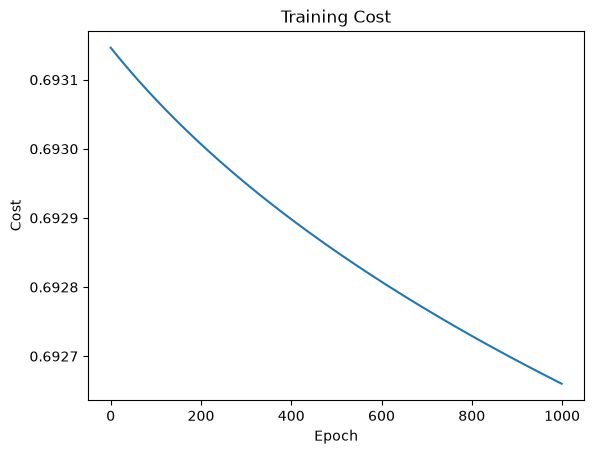

In [113]:
plt.plot(cost_history)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Training Cost")
plt.show()

In [114]:
weights = np.zeros(n_features)
bias = 0.0

In [115]:
learning_rate = 0.1
epochs = 1000

cost_history = []

for epoch in range(epochs):
    # Forward pass
    z = X_train_np @ weights + bias
    probabilities = sigmoid(z)

    # Cost
    cost = binary_cross_entropy(y_train_np, probabilities)
    cost_history.append(cost)

    # Gradients
    dw = (1 / len(X_train_np)) * (
        X_train_np.T @ (probabilities - y_train_np)
    )
    db = (1 / len(X_train_np)) * np.sum(
        probabilities - y_train_np
    )

    # Update
    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

In [116]:
print("Initial cost:", cost_history[0])
print("Final cost:", cost_history[-1])

Initial cost: 0.6931471805599453
Final cost: 0.691707045342626


In [117]:
train_probabilities = sigmoid(X_train_np @ weights + bias)

train_predictions = (train_probabilities >= 0.5).astype(int)

train_accuracy = np.mean(train_predictions == y_train_np)

print("Training accuracy:", train_accuracy)

Training accuracy: 0.5218164637874493


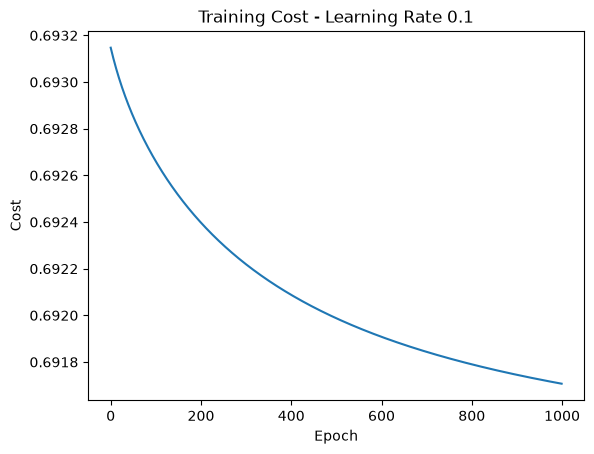

In [118]:
plt.plot(cost_history)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Training Cost - Learning Rate 0.1")
plt.show()

In [119]:
weights = np.zeros(n_features)
bias = 0.0

In [120]:
learning_rate = 0.1
epochs = 10000

cost_history = []

for epoch in range(epochs):
    z = X_train_np @ weights + bias
    probabilities = sigmoid(z)

    cost = binary_cross_entropy(y_train_np, probabilities)
    cost_history.append(cost)

    dw = (1 / len(X_train_np)) * (
        X_train_np.T @ (probabilities - y_train_np)
    )
    db = (1 / len(X_train_np)) * np.sum(
        probabilities - y_train_np
    )

    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

In [121]:
print("Initial cost:", cost_history[0])
print("Final cost:", cost_history[-1])

train_probabilities = sigmoid(X_train_np @ weights + bias)
train_predictions = (train_probabilities >= 0.5).astype(int)

train_accuracy = np.mean(train_predictions == y_train_np)

print("Training accuracy:", train_accuracy)

Initial cost: 0.6931471805599453
Final cost: 0.6910854064956571
Training accuracy: 0.5260963815240954


In [122]:
print("Probability range:")
print("Minimum:", train_probabilities.min())
print("Maximum:", train_probabilities.max())

print("\nProbability mean:", train_probabilities.mean())

print("\nWeight range:")
print("Minimum:", weights.min())
print("Maximum:", weights.max())

print("\nGradient magnitude:", np.linalg.norm(dw))

Probability range:
Minimum: 0.3488643875162044
Maximum: 0.6245906176401257

Probability mean: 0.5001460542740779

Weight range:
Minimum: -0.32999808765398836
Maximum: 0.22993216184176837

Gradient magnitude: 0.0004629209438095894


In [123]:
weights = np.zeros(n_features)
bias = 0.0

In [124]:
learning_rate = 1.0
epochs = 5000

cost_history = []

for epoch in range(epochs):
    z = X_train_np @ weights + bias
    probabilities = sigmoid(z)

    cost = binary_cross_entropy(y_train_np, probabilities)
    cost_history.append(cost)

    dw = (1 / len(X_train_np)) * (
        X_train_np.T @ (probabilities - y_train_np)
    )
    db = (1 / len(X_train_np)) * np.sum(
        probabilities - y_train_np
    )

    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

In [125]:
print("Initial cost:", cost_history[0])
print("Final cost:", cost_history[-1])

train_probabilities = sigmoid(X_train_np @ weights + bias)
train_predictions = (train_probabilities >= 0.5).astype(int)

train_accuracy = np.mean(train_predictions == y_train_np)

print("Training accuracy:", train_accuracy)

Initial cost: 0.6931471805599453
Final cost: 0.6909142719902192
Training accuracy: 0.5267077983436163


In [126]:
weights = np.zeros(n_features)
bias = 0.0

In [127]:
learning_rate = 5.0
epochs = 5000

cost_history = []

for epoch in range(epochs):
    z = X_train_np @ weights + bias
    probabilities = sigmoid(z)

    cost = binary_cross_entropy(y_train_np, probabilities)
    cost_history.append(cost)

    dw = (1 / len(X_train_np)) * (
        X_train_np.T @ (probabilities - y_train_np)
    )
    db = (1 / len(X_train_np)) * np.sum(
        probabilities - y_train_np
    )

    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

In [128]:
print("Initial cost:", cost_history[0])
print("Final cost:", cost_history[-1])

train_probabilities = sigmoid(X_train_np @ weights + bias)
train_predictions = (train_probabilities >= 0.5).astype(int)

train_accuracy = np.mean(train_predictions == y_train_np)

print("Training accuracy:", train_accuracy)

Initial cost: 0.6931471805599453
Final cost: 1.153896480078287
Training accuracy: 0.5003057084097604


In [129]:
weights = np.zeros(n_features)
bias = 0.0

learning_rate = 1.0
epochs = 5000

cost_history = []

for epoch in range(epochs):
    z = X_train_np @ weights + bias
    probabilities = sigmoid(z)

    cost = binary_cross_entropy(y_train_np, probabilities)
    cost_history.append(cost)

    dw = (1 / len(X_train_np)) * (
        X_train_np.T @ (probabilities - y_train_np)
    )
    db = (1 / len(X_train_np)) * np.sum(
        probabilities - y_train_np
    )

    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

In [130]:
val_probabilities = sigmoid(X_val_np @ weights + bias)

val_predictions = (val_probabilities >= 0.5).astype(int)

In [131]:
val_accuracy = np.mean(val_predictions == y_val_np)

print("Validation accuracy:", val_accuracy)

Validation accuracy: 0.49911071587372163


In [132]:
crime_closure_rate = train.groupby("crime_description")["closed"].apply(
    lambda x: (x == "Yes").mean()
)

print(crime_closure_rate.sort_values(ascending=False))

crime_description
FRAUD                  0.525199
IDENTITY THEFT         0.521983
DOMESTIC VIOLENCE      0.518877
TRAFFIC VIOLATION      0.510758
VEHICLE - STOLEN       0.509671
ILLEGAL POSSESSION     0.508118
PUBLIC INTOXICATION    0.507922
HOMICIDE               0.506058
ASSAULT                0.502334
SEXUAL ASSAULT         0.499062
KIDNAPPING             0.498127
ROBBERY                0.497243
VANDALISM              0.495455
SHOPLIFTING            0.495192
EXTORTION              0.494665
FIREARM OFFENSE        0.492606
BURGLARY               0.487109
COUNTERFEITING         0.487061
CYBERCRIME             0.485213
DRUG OFFENSE           0.484651
ARSON                  0.481175
Name: closed, dtype: float64


In [133]:
for column in ["city", "sex", "weapon", "domain", "police_department"]:
    print(f"\n--- {column} ---")

    closure_rate = train.groupby(column)["closed"].apply(
        lambda x: (x == "Yes").mean()
    )

    print(closure_rate.sort_values(ascending=False).head(10))


--- city ---
city
Ludhiana     0.543210
Lucknow      0.520782
Rajkot       0.520231
Vasai        0.519048
Kanpur       0.516854
Nagpur       0.515789
Meerut       0.515419
Jaipur       0.513357
Hyderabad    0.511768
Nashik       0.509901
Name: closed, dtype: float64

--- sex ---
sex
X    0.508758
F    0.499801
M    0.498599
Name: closed, dtype: float64

--- weapon ---
weapon
Other           0.513195
Poison          0.509852
Missing         0.507029
Blunt Object    0.502063
Knife           0.498629
Firearm         0.489490
Explosives      0.481727
Name: closed, dtype: float64

--- domain ---
domain
Traffic Fatality    0.510758
Violent Crime       0.508096
Other Crime         0.497983
Fire Accident       0.486872
Name: closed, dtype: float64

--- police_department ---
police_department
 34.9    0.606061
 30.9    0.600000
 8.9     0.593407
 23.9    0.586207
-4.1     0.544444
 36.9    0.543478
 29.9    0.542857
 28.9    0.535714
 6.0     0.534515
 2.9     0.533333
Name: closed, dtype: flo

In [134]:
print(train.groupby("closed")[["age", "area"]].mean())

print("\nDate features:")
print(train.groupby("closed")[["year", "month", "hour"]].mean())

              age        area
closed                       
No      44.851994  352.664382
Yes     44.705607  351.424242

Date features:
               year     month       hour
closed                                  
No      2021.808740  6.240566  11.491812
Yes     2021.813916  6.220741  11.566071


In [135]:
val_cost = binary_cross_entropy(y_val_np, val_probabilities)

print("Validation cost:", val_cost)

Validation cost: 0.6963331868873772


In [136]:
TP = np.sum((val_predictions == 1) & (y_val_np == 1))
TN = np.sum((val_predictions == 0) & (y_val_np == 0))
FP = np.sum((val_predictions == 1) & (y_val_np == 0))
FN = np.sum((val_predictions == 0) & (y_val_np == 1))

print("True Positives:", TP)
print("True Negatives:", TN)
print("False Positives:", FP)
print("False Negatives:", FN)

True Positives: 1124
True Negatives: 1121
False Positives: 1122
False Negatives: 1131


In [137]:
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.5004452359750667
Recall: 0.4984478935698448
F1-score: 0.49944456787380587


In [138]:
X_test = test.copy()

X_test["weapon"] = X_test["weapon"].fillna("Missing")

X_test["case_filed"] = pd.to_datetime(X_test["case_filed"])

X_test["year"] = X_test["case_filed"].dt.year
X_test["month"] = X_test["case_filed"].dt.month
X_test["hour"] = X_test["case_filed"].dt.hour

X_test = X_test.drop(
    columns=["Unnamed: 0", "Num", "case_filed"]
)

In [139]:
X_test = pd.get_dummies(
    X_test,
    columns=categorical_columns,
    dtype=int
)

In [140]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("X_test shape:", X_test.shape)

X_test shape: (9639, 126)


In [141]:
X_test[numeric_features] = (
    X_test[numeric_features] - train_mean
) / train_std

In [142]:
X_test_np = X_test.to_numpy(dtype=float)

print("X_test_np shape:", X_test_np.shape)

X_test_np shape: (9639, 126)


In [143]:
test_probabilities = sigmoid(X_test_np @ weights + bias)

print("First 10 probabilities:")
print(test_probabilities[:10])

First 10 probabilities:
[0.48420697 0.51074765 0.50710311 0.54026614 0.52179252 0.48768013
 0.50840394 0.5298244  0.4840621  0.54447393]


In [144]:
test_predictions = (test_probabilities >= 0.5).astype(int)

print("First 20 predictions:")
print(test_predictions[:20])

print("\nPrediction counts:")
print(pd.Series(test_predictions).value_counts())

First 20 predictions:
[0 1 1 1 1 0 1 1 0 1 1 0 0 0 1 0 0 0 1 0]

Prediction counts:
1    4912
0    4727
Name: count, dtype: int64


In [145]:

print("=" * 50)
print("       LOGISTIC REGRESSION — TEST SUMMARY")
print("=" * 50)

# 1. Dataset overview
print("\n1. DATASET OVERVIEW")
print("-" * 30)
print("Test dataset shape:", test.shape)
print("Number of test cases:", len(test))
print("Number of features used:", X_test_np.shape[1])
print("Missing values in original test data:", test.isnull().sum().sum())

# 2. Prediction distribution
print("\n2. PREDICTION DISTRIBUTION")
print("-" * 30)
closed_count = np.sum(test_predictions == 1)
unresolved_count = np.sum(test_predictions == 0)

print("Predicted Closed (1):", closed_count)
print("Predicted Unresolved (0):", unresolved_count)
print("Total predictions:", len(test_predictions))
print("Closed percentage:", round(closed_count / len(test_predictions) * 100, 2), "%")
print("Unresolved percentage:", round(unresolved_count / len(test_predictions) * 100, 2), "%")

# 3. Probability statistics
print("\n3. PREDICTED PROBABILITY STATISTICS")
print("-" * 30)
print("Mean probability:", round(test_probabilities.mean(), 4))
print("Minimum probability:", round(test_probabilities.min(), 4))
print("Maximum probability:", round(test_probabilities.max(), 4))
print("Standard deviation:", round(test_probabilities.std(), 4))

# 4. Sample predictions
print("\n4. FIRST 10 PREDICTIONS")
print("-" * 30)

summary = pd.DataFrame({
    "Predicted Probability": test_probabilities[:10],
    "Predicted Label": test_predictions[:10],
    "Predicted Status": np.where(
        test_predictions[:10] == 1, "Closed", "Unresolved"
    )
})

print(summary.to_string(index=True))

# 5. Final checks
print("\n5. FINAL CHECKS")
print("-" * 30)
print("All probabilities valid:",
      np.all((test_probabilities >= 0) & (test_probabilities <= 1)))
print("All predictions binary:",
      np.all(np.isin(test_predictions, [0, 1])))
print("Prediction count matches test rows:",
      len(test_predictions) == len(test))

print("\nNote: Test accuracy cannot be calculated without true labels.")
print("=" * 50)


       LOGISTIC REGRESSION — TEST SUMMARY

1. DATASET OVERVIEW
------------------------------
Test dataset shape: (9639, 12)
Number of test cases: 9639
Number of features used: 126
Missing values in original test data: 1364

2. PREDICTION DISTRIBUTION
------------------------------
Predicted Closed (1): 4912
Predicted Unresolved (0): 4727
Total predictions: 9639
Closed percentage: 50.96 %
Unresolved percentage: 49.04 %

3. PREDICTED PROBABILITY STATISTICS
------------------------------
Mean probability: 0.5003
Minimum probability: 0.3142
Maximum probability: 0.6502
Standard deviation: 0.033

4. FIRST 10 PREDICTIONS
------------------------------
   Predicted Probability  Predicted Label Predicted Status
0               0.484207                0       Unresolved
1               0.510748                1           Closed
2               0.507103                1           Closed
3               0.540266                1           Closed
4               0.521793                1          